# 01 新聞資料品質檢查

本 notebook 僅讀取本地 SQLite 資料庫，不呼叫 Groq 或任何外部 API。

檢查項目：
1. 原始新聞基本統計（筆數、來源、日期範圍）
2. 每日爬取量趨勢
3. 重複新聞檢查（相同 URL）
4. 標題文字長度分布
5. LLM 分析覆蓋率與失敗原因
6. 標的分布（target coverage）

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "backend" / "data" / "twstock_sentiment.db"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.unicode_minus"] = False

print(f"DB: {DB_PATH}  (exists={DB_PATH.exists()})")

DB: C:\python_data_analysis_final\backend\data\twstock_sentiment.db  (exists=True)


## 1. 載入資料

In [2]:
with sqlite3.connect(DB_PATH) as conn:
    raw = pd.read_sql_query(
        "SELECT id, title, url, published_at, source FROM raw_news ORDER BY published_at",
        conn,
    )
    llm = pd.read_sql_query(
        "SELECT news_id, status, target, news_type, sentiment, confidence, model_name FROM llm_news_analysis",
        conn,
    )

raw["published_at"] = pd.to_datetime(raw["published_at"], utc=True, errors="coerce")
raw["date"] = raw["published_at"].dt.date
raw["title_len"] = raw["title"].str.len()

print(f"raw_news rows   : {len(raw):,}")
print(f"llm_news rows   : {len(llm):,}")
print(f"date range      : {raw['published_at'].min().date()} ~ {raw['published_at'].max().date()}")
raw.head()

raw_news rows   : 1,345
llm_news rows   : 1,315
date range      : 2026-03-06 ~ 2026-05-18


,id,title,url,published_at,source,date,title_len
0,256,外資賣超352.36億元 砍元大台灣50逾7萬張最多,https://tw.stock.yahoo.com/news/%E5%A4%96%E8%B...,2026-03-06 09:12:00+00:00,Yahoo Stock News,2026-03-06,26
1,255,外資砍1208億創史上最大賣超金額 調節0050、台積電,https://tw.stock.yahoo.com/news/%E5%A4%96%E8%B...,2026-03-09 10:58:16+00:00,Yahoo Stock News,2026-03-09,28
2,254,外資賣超711.27億元 砍元大台灣50逾7萬張最多,https://tw.stock.yahoo.com/news/%E5%A4%96%E8%B...,2026-03-12 09:31:21+00:00,Yahoo Stock News,2026-03-12,26
3,253,外資賣超909億元創史上第8大 大砍0050排第1,https://tw.stock.yahoo.com/news/%E5%A4%96%E8%B...,2026-03-19 08:34:38+00:00,Yahoo Stock News,2026-03-19,25
4,324,中東戰局推升台股震盪 「這一招」荷包收息,https://tw.news.yahoo.com/%E4%B8%AD%E6%9D%B1%E...,NaT,Yahoo News,NaT,20


## 2. 來源分布

C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2726445136.py:10: UserWarning: Glyph 20358 (\N{CJK UNIFIED IDEOGRAPH-4F86}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2726445136.py:10: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2726445136.py:10: UserWarning: Glyph 31558 (\N{CJK UNIFIED IDEOGRAPH-7B46}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2726445136.py:10: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2726445136.py:10: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2726445136.py:10: UserWarning: Glyph 32862 (\N{CJK UNIFIED IDEOGRAPH-805E}) missi

C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31558 (\N{CJK UNIFIED IDEOGRAPH-7B46}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32862 (\N{CJK UNIFIED IDEOGRAPH-805E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20358 (\N{CJK UNIFIED IDEOGRAPH-4F86}) missing from font(s) Arial.
  fig.canvas.print_figure(b

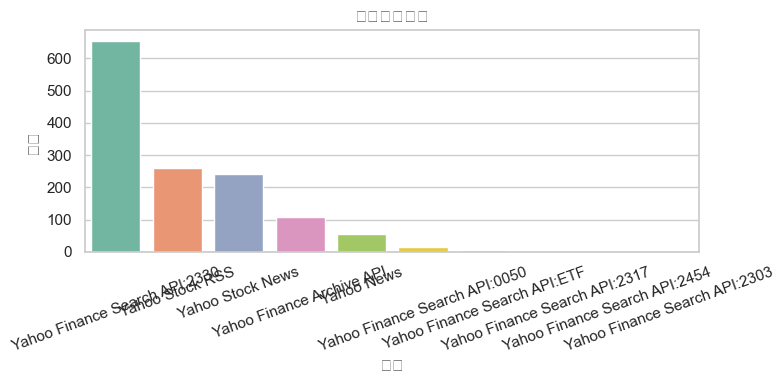

,source,count,ratio
0,Yahoo Finance Search API:2330,654,0.486245
1,Yahoo Stock RSS,261,0.194052
2,Yahoo Stock News,242,0.179926
3,Yahoo Finance Archive API,108,0.080297
4,Yahoo News,56,0.041636
5,Yahoo Finance Search API:0050,15,0.011152
6,Yahoo Finance Search API:ETF,5,0.003717
7,Yahoo Finance Search API:2317,2,0.001487
8,Yahoo Finance Search API:2454,1,0.000743
9,Yahoo Finance Search API:2303,1,0.000743


In [3]:
source_dist = raw["source"].value_counts().rename_axis("source").reset_index(name="count")
source_dist["ratio"] = source_dist["count"] / source_dist["count"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=source_dist, x="source", y="count", ax=ax, hue="source", legend=False, palette="Set2")
ax.set_title("新聞來源分布")
ax.set_xlabel("來源")
ax.set_ylabel("筆數")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "news_source_distribution.png", dpi=160)
plt.show()
display(source_dist)

## 3. 每日爬取量趨勢

C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2411618826.py:12: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2411618826.py:12: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2411618826.py:12: UserWarning: Glyph 31558 (\N{CJK UNIFIED IDEOGRAPH-7B46}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2411618826.py:12: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2411618826.py:12: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\2411618826.py:12: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missi

C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31558 (\N{CJK UNIFIED IDEOGRAPH-7B46}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) Arial.
  fig.canvas.print_figure(b

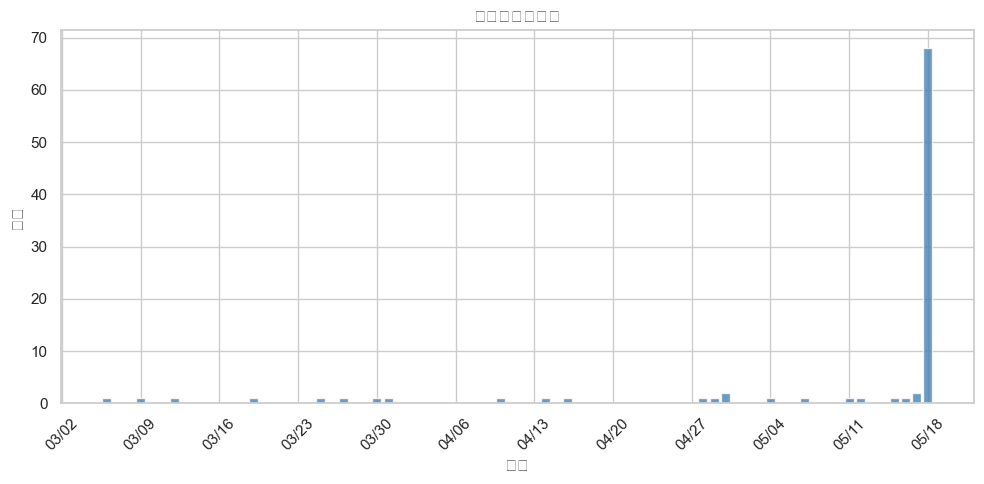

平均每日: 4.1 則  |  最多: 68 則  |  共 22 個日期


In [4]:
daily_count = raw.groupby("date").size().reset_index(name="count")
daily_count["date"] = pd.to_datetime(daily_count["date"])

fig, ax = plt.subplots()
ax.bar(daily_count["date"], daily_count["count"], width=0.8, color="steelblue", alpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.xticks(rotation=45)
ax.set_title("每日新聞爬取量")
ax.set_xlabel("日期")
ax.set_ylabel("筆數")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "news_daily_count.png", dpi=160)
plt.show()
print(f"平均每日: {daily_count['count'].mean():.1f} 則  |  最多: {daily_count['count'].max()} 則  |  共 {len(daily_count)} 個日期")

## 4. 重複新聞檢查

In [5]:
dup_url = raw[raw.duplicated(subset=["url"], keep=False)].sort_values("url")
dup_title = raw[raw.duplicated(subset=["title"], keep=False)].sort_values("title")

print(f"重複 URL 數量   : {len(dup_url):,} 筆（{dup_url['url'].nunique()} 個不重複 URL 出現 2 次以上）")
print(f"重複標題數量    : {len(dup_title):,} 筆（{dup_title['title'].nunique()} 個不重複標題出現 2 次以上）")

if len(dup_url) > 0:
    display(Markdown("### 重複 URL 範例（前 5 個）"))
    display(dup_url[["id","title","url","published_at"]].head(10))
else:
    display(Markdown("✅ 無重複 URL — 爬蟲的 URL 去重機制正常運作"))

重複 URL 數量   : 0 筆（0 個不重複 URL 出現 2 次以上）
重複標題數量    : 23 筆（2 個不重複標題出現 2 次以上）


✅ 無重複 URL — 爬蟲的 URL 去重機制正常運作

## 5. 標題文字長度分布

C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\3102327216.py:8: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\3102327216.py:8: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\3102327216.py:8: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\3102327216.py:8: UserWarning: Glyph 31687 (\N{CJK UNIFIED IDEOGRAPH-7BC7}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\3102327216.py:8: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\3102327216.py:8: UserWarning: Glyph 32862 (\N{CJK UNIFIED IDEOGRAPH-805E}) missing fro

C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31687 (\N{CJK UNIFIED IDEOGRAPH-7BC7}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38988 (\N{CJK UNIFIED IDEOGRAPH-984C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  fig.canvas.print_figure(b

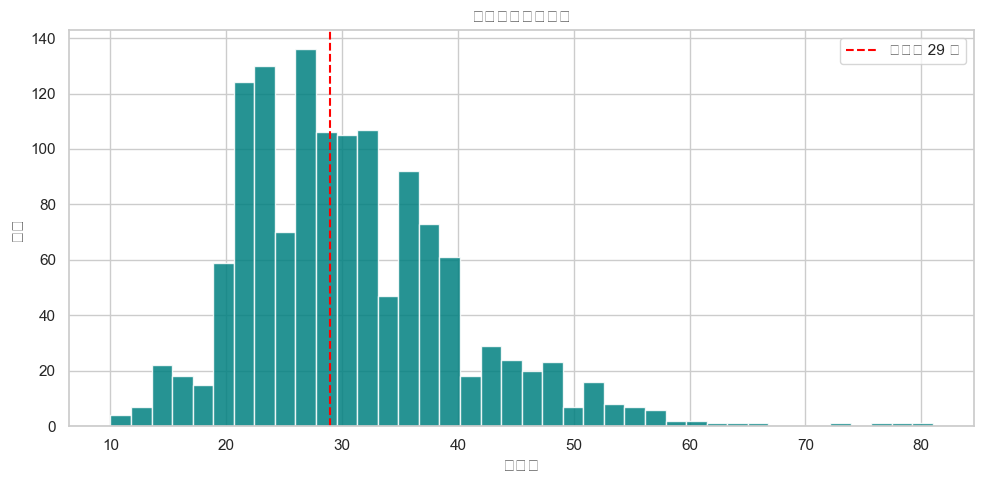

count    1345.000000
mean       30.565799
std         9.293832
min        10.000000
25%        24.000000
50%        29.000000
75%        36.000000
max        81.000000


In [6]:
fig, ax = plt.subplots()
ax.hist(raw["title_len"].dropna(), bins=40, color="teal", edgecolor="white", alpha=0.85)
ax.axvline(raw["title_len"].median(), color="red", linestyle="--", label=f"中位數 {raw['title_len'].median():.0f} 字")
ax.set_title("新聞標題長度分布")
ax.set_xlabel("字元數")
ax.set_ylabel("篇數")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "news_title_length.png", dpi=160)
plt.show()

print(raw["title_len"].describe().to_string())

## 6. LLM 分析覆蓋率

C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\1687465908.py:16: UserWarning: Glyph 29376 (\N{CJK UNIFIED IDEOGRAPH-72C0}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\1687465908.py:16: UserWarning: Glyph 24907 (\N{CJK UNIFIED IDEOGRAPH-614B}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\1687465908.py:16: UserWarning: Glyph 31558 (\N{CJK UNIFIED IDEOGRAPH-7B46}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\1687465908.py:16: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\1687465908.py:16: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\1687465908.py:16: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missi

C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31558 (\N{CJK UNIFIED IDEOGRAPH-7B46}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29376 (\N{CJK UNIFIED IDEOGRAPH-72C0}) missing from font(s) Arial.
  fig.canvas.print_figure(b

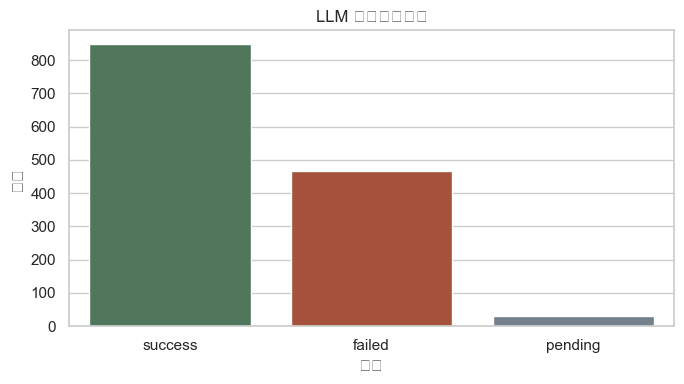

,status,count,ratio
0,success,847,0.629740
1,failed,468,0.347955
2,pending,30,0.022305


LLM 成功率：63.0%


In [7]:
analyzed_ids = set(llm["news_id"])
raw["llm_status"] = raw["id"].map(
    llm.set_index("news_id")["status"]
).fillna("pending")

status_counts = raw["llm_status"].value_counts().rename_axis("status").reset_index(name="count")
status_counts["ratio"] = status_counts["count"] / status_counts["count"].sum()

fig, ax = plt.subplots(figsize=(7, 4))
colors = {"success": "#4a7c59", "failed": "#b7472a", "pending": "#708090"}
bar_colors = [colors.get(s, "gray") for s in status_counts["status"]]
sns.barplot(data=status_counts, x="status", y="count", ax=ax, palette=bar_colors, hue="status", legend=False)
ax.set_title("LLM 分析狀態分布")
ax.set_xlabel("狀態")
ax.set_ylabel("筆數")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "llm_status_distribution.png", dpi=160)
plt.show()

display(status_counts)
success_n = status_counts.loc[status_counts["status"]=="success", "count"].sum()
print(f"LLM 成功率：{success_n / len(raw):.1%}")

## 7. 標的分布（Target Coverage）

C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\4218428663.py:16: UserWarning: Glyph 26230 (\N{CJK UNIFIED IDEOGRAPH-6676}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\4218428663.py:16: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\4218428663.py:16: UserWarning: Glyph 21322 (\N{CJK UNIFIED IDEOGRAPH-534A}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\4218428663.py:16: UserWarning: Glyph 23566 (\N{CJK UNIFIED IDEOGRAPH-5C0E}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\4218428663.py:16: UserWarning: Glyph 39636 (\N{CJK UNIFIED IDEOGRAPH-9AD4}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\0720s\AppData\Local\Temp\ipykernel_8716\4218428663.py:16: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missi

C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31558 (\N{CJK UNIFIED IDEOGRAPH-7B46}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\0720s\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) Arial.
  fig.canvas.print_figure(b

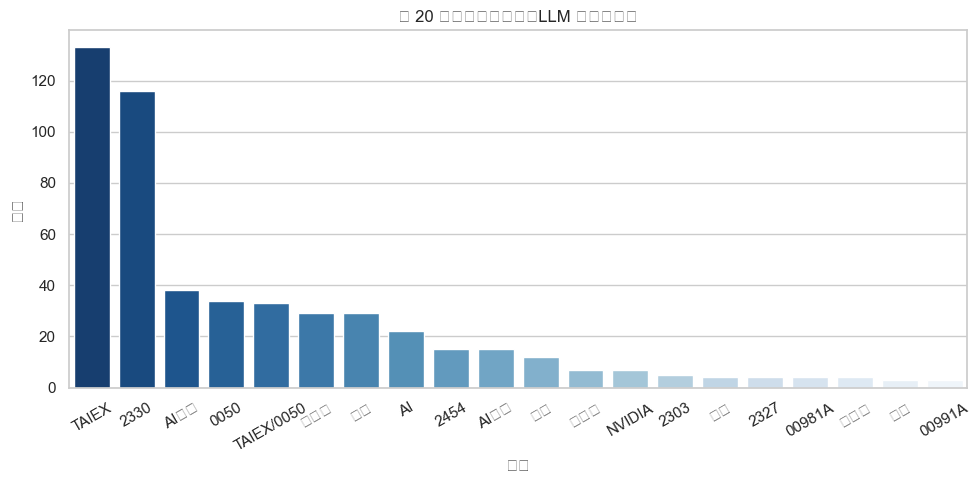

,target,count
0,TAIEX,133
1,2330,116
2,AI晶片,38
3,0050,34
4,TAIEX/0050,33
5,半導體,29
6,台灣,29
7,AI,22
8,2454,15
9,AI應用,15


In [8]:
success_llm = llm[llm["status"] == "success"].copy()
target_dist = (
    success_llm["target"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=target_dist, x="target", y="count", ax=ax, hue="target", legend=False, palette="Blues_r")
ax.set_title("前 20 大標的新聞筆數（LLM 成功分析）")
ax.set_xlabel("標的")
ax.set_ylabel("筆數")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_distribution.png", dpi=160)
plt.show()

display(target_dist)

## 8. 資料品質摘要

In [9]:
summary = {
    "原始新聞總筆數": len(raw),
    "日期範圍": f"{raw['published_at'].min().date()} ~ {raw['published_at'].max().date()}",
    "資料天數": raw["date"].nunique(),
    "來源種類": raw["source"].nunique(),
    "重複 URL 筆數": len(dup_url),
    "LLM 成功分析": int(status_counts.loc[status_counts["status"]=="success", "count"].sum() if "success" in status_counts["status"].values else 0),
    "LLM 失敗": int(status_counts.loc[status_counts["status"]=="failed", "count"].sum() if "failed" in status_counts["status"].values else 0),
    "待分析 (pending)": int(status_counts.loc[status_counts["status"]=="pending", "count"].sum() if "pending" in status_counts["status"].values else 0),
    "平均標題長度 (字)": f"{raw['title_len'].mean():.1f}",
    "出現的股票代號": success_llm["target"].nunique(),
}

summary_df = pd.DataFrame(list(summary.items()), columns=["項目", "數值"])
summary_df.to_csv(TABLE_DIR / "news_data_quality_summary.csv", index=False, encoding="utf-8-sig")
display(summary_df)

,項目,數值
0,原始新聞總筆數,1345
1,日期範圍,2026-03-06 ~ 2026-05-18
2,資料天數,22
3,來源種類,10
4,重複 URL 筆數,0
5,LLM 成功分析,847
6,LLM 失敗,468
7,待分析 (pending),30
8,平均標題長度 (字),30.6
9,出現的股票代號,234
